# YOLO11n-Seg 파손율 계산 파이프라인

**목표**: YOLO11n-seg로 `total`과 `damage` 마스크를 학습하고, `damage/total` 비율로 파손율 계산

**전체 흐름**:
1. 환경 설정
2. Roboflow에서 데이터셋 다운로드
3. 데이터셋 구조 및 라벨 확인
4. YOLO11n-Seg 모델 학습 (train + valid 자동 사용)
5. 학습 결과 평가 (valid + test)
6. 추론 및 파손율 계산 (단일 이미지)
7. 배치 파손율 계산 (test set 전체)

> ⚠️ **보안 주의**: Roboflow API 키는 외부에 노출되면 안 됩니다. 공유용 노트북에선 꼭 제거하거나 환경변수로 관리하세요.

## 1. 환경 설정

In [1]:
# 최초 1회만 실행
%pip install ultralytics roboflow opencv-python matplotlib pandas pyyaml -q

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
torch.cuda.empty_cache()

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import yaml
import pandas as pd
from pathlib import Path
from PIL import Image
from ultralytics import YOLO
import torch

# GPU 확인
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 2080
VRAM: 8.2 GB


## 2. Roboflow에서 데이터셋 다운로드

`dataset.location`이 다운로드된 폴더 경로를 알려주므로 `DATASET_DIR`을 자동으로 잡습니다.

In [ ]:
from roboflow import Roboflow

# ⚠️ API 키를 재발급받은 새 키로 교체하세요!
# 환경변수 방식 권장: os.environ['ROBOFLOW_API_KEY'] = '...'
api_key = ""  # ← 여기에 새 키 입력

rf = Roboflow(api_key="")
project = rf.workspace("").project("")
version = project.version(1)
dataset = version.download("yolov8")


# 다운로드된 폴더 경로 자동 획득
DATASET_DIR = Path(dataset.location)
print(f"\n✓ 데이터셋 위치: {DATASET_DIR.resolve()}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to 506-1 in yolov8:: 100%|██████████| 322/322 [00:01<00:00, 259.37it/s]



✓ 데이터셋 위치: /home/piai/바탕화면/YOLO/506-1


In [57]:
DATASET_DIR = Path("/home/piai/바탕화면/YOLO/전체")
print(f"\n✓ 데이터셋 위치: {DATASET_DIR.resolve()}")


✓ 데이터셋 위치: /home/piai/바탕화면/YOLO/전체


## 3. 데이터셋 구조 및 라벨 확인

In [58]:
# train/valid/test 분할 확인
print("=" * 40)
print("📁 데이터셋 분할 현황")
print("=" * 40)
total_count = 0
split_counts = {}
for sub in ["train", "valid", "test"]:
    img_dir = DATASET_DIR / sub / "images"
    lbl_dir = DATASET_DIR / sub / "labels"
    if img_dir.exists():
        n_img = len(list(img_dir.glob("*.*")))
        n_lbl = len(list(lbl_dir.glob("*.txt"))) if lbl_dir.exists() else 0
        split_counts[sub] = n_img
        total_count += n_img
        print(f"{sub:6s}: images={n_img:4d}, labels={n_lbl:4d}")
    else:
        print(f"{sub:6s}: 폴더 없음")

print("-" * 40)
print(f"총계  : {total_count}장")
if total_count > 0:
    print("\n분할 비율:")
    for sub, n in split_counts.items():
        print(f"  {sub}: {n/total_count*100:.1f}%")

# data.yaml 원본 확인
yaml_path = DATASET_DIR / "data.yaml"
if yaml_path.exists():
    print("\n=== 원본 data.yaml ===")
    print(yaml_path.read_text())

📁 데이터셋 분할 현황
train : images=1079, labels=1080
valid : 폴더 없음
test  : 폴더 없음
----------------------------------------
총계  : 1079장

분할 비율:
  train: 100.0%

=== 원본 data.yaml ===
path: /home/piai/바탕화면/YOLO/전체
train: train/images
val: valid/images
test: test/images
nc: 2
names:
- damage
- total



In [59]:
# data.yaml을 절대경로로 재작성 (Roboflow 상대경로 이슈 방지)
with open(DATASET_DIR / "data.yaml", "r") as f:
    original = yaml.safe_load(f)

class_names = original.get("names", ["total", "damage"])
print(f"클래스: {class_names}")

data_yaml_content = {
    "path": str(DATASET_DIR.resolve()),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": len(class_names),
    "names": class_names,
}

with open(DATASET_DIR / "data.yaml", "w") as f:
    yaml.dump(data_yaml_content, f, sort_keys=False, allow_unicode=True)

print("\n=== 업데이트된 data.yaml ===")
print((DATASET_DIR / "data.yaml").read_text())

클래스: ['damage', 'total']

=== 업데이트된 data.yaml ===
path: /home/piai/바탕화면/YOLO/전체
train: train/images
val: valid/images
test: test/images
nc: 2
names:
- damage
- total



In [60]:
# 라벨 포맷 확인 (seg polygon인지 detection bbox인지)
sample_lbl = next((DATASET_DIR / "train/labels").glob("*.txt"))
print(f"샘플 라벨 파일: {sample_lbl.name}")
print("-" * 50)
lines = sample_lbl.read_text().strip().split("\n")
for i, line in enumerate(lines[:3]):
    parts = line.split()
    n_coords = len(parts) - 1
    print(f"Line {i+1}: 클래스={parts[0]}, 좌표 {n_coords}개 ({n_coords//2}쌍)")
    if n_coords >= 6:
        print(f"  → ✅ Segmentation polygon 포맷")
    elif n_coords == 4:
        print(f"  → ❌ Detection bbox 포맷! Roboflow에서 Segmentation으로 다시 다운로드 필요")
    print()

샘플 라벨 파일: 504_10_0a73e771-bc32-49ef-ad19-1a00d14a6a2c_jpeg.rf.1c12221bfc94c159afd39ed148f68206.txt
--------------------------------------------------
Line 1: 클래스=1, 좌표 10개 (5쌍)
  → ✅ Segmentation polygon 포맷



Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
Glyph 48296 (\N{HANGUL SYLLABLE BEL}) missing from font(s) DejaVu Sans.
Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
Glyph 48296 (\N{HANGUL SYLLABLE BEL}) missing from font(s) DejaVu Sans.
Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaV

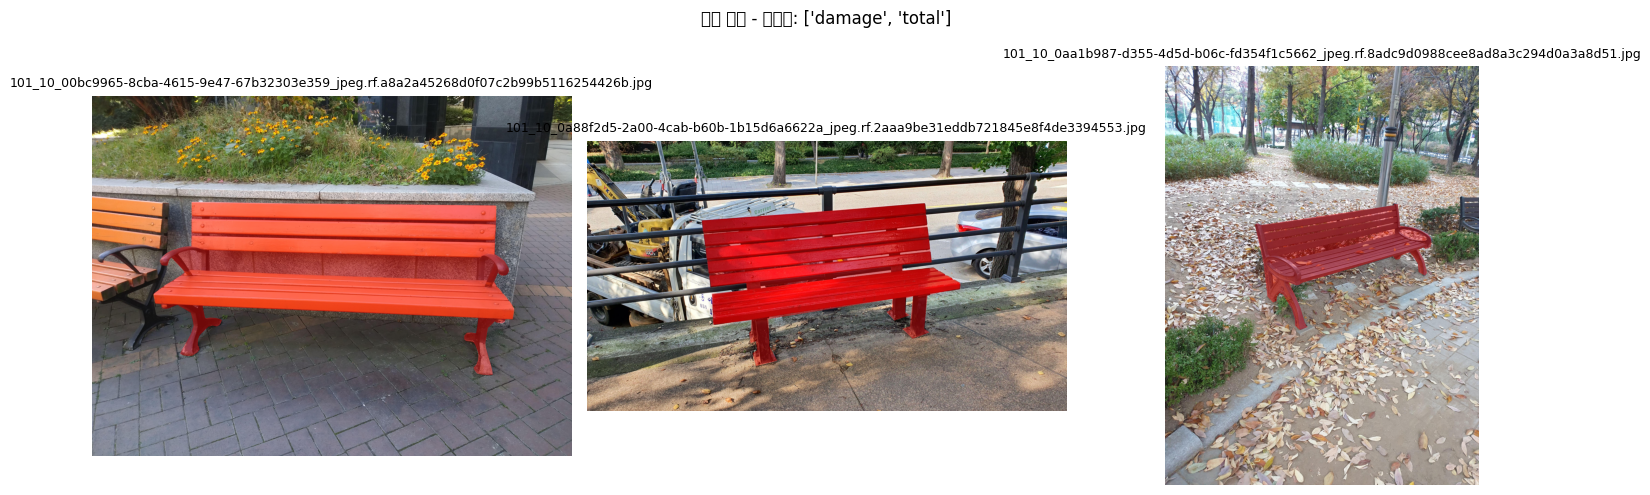

In [61]:
# 라벨 시각화로 눈으로 확인
def visualize_label(img_path, lbl_path, colors=None):
    if colors is None:
        colors = [(0, 255, 0), (255, 0, 0), (0, 0, 255), (255, 255, 0)]
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    overlay = img.copy()
    
    for line in lbl_path.read_text().strip().split("\n"):
        parts = line.split()
        if len(parts) < 7:
            continue
        cls = int(parts[0])
        coords = np.array([float(x) for x in parts[1:]]).reshape(-1, 2)
        coords[:, 0] *= w
        coords[:, 1] *= h
        coords = coords.astype(np.int32)
        cv2.fillPoly(overlay, [coords], colors[cls % len(colors)])
    
    return cv2.addWeighted(img, 0.6, overlay, 0.4, 0)

img_files = sorted((DATASET_DIR / "train/images").glob("*.*"))[:3]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img_path in zip(axes, img_files):
    lbl_path = DATASET_DIR / "train/labels" / (img_path.stem + ".txt")
    if lbl_path.exists():
        vis = visualize_label(img_path, lbl_path)
        ax.imshow(vis)
        ax.set_title(img_path.name, fontsize=9)
        ax.axis("off")
plt.suptitle(f"라벨 확인 - 클래스: {class_names}")
plt.tight_layout()
plt.show()

## 4. YOLO11n-Seg 학습

**사용 모델**: `yolo11n-seg` (nano, 2.9M 파라미터 - 가볍고 빠름)

- **학습 데이터**: train (자동)
- **검증 데이터**: valid (매 에폭마다 성능 측정, early stopping 기준)
- **테스트 데이터**: test (섹션 5에서 사용)

> `data.yaml`에 train/val 경로가 적혀 있어서 YOLO가 자동 사용합니다.

In [62]:
# nano 사전학습 가중치 로드 (처음 실행 시 자동 다운로드)
model = YOLO("yolov8s-seg.pt")

# 성능 부족 시 대안: yolo11s-seg.pt, yolo11m-seg.pt

In [64]:
# 학습 실행
results = model.train(
    data=str(DATASET_DIR / "data.yaml"),
    epochs=150,
    patience=30,
    imgsz=896,              # damage가 작게 나타나면 896으로 올리기
    batch=4,               # nano는 가벼워서 32 가능 (OOM 시 16으로)
    optimizer="AdamW",
    lr0=0.001,
    cos_lr=True,
    cache=False,            # RAM 여유 없으면 False
    
    # Augmentation (마스크도 자동 변환, 매 에폭 다르게 적용)
    mosaic=1.0,
    mixup=0.15,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    flipud=0.0,
    copy_paste=0.0,
    
    # 저장
    project="damage_seg",
    name="yolov8s_v1",
    save=True,
    save_period=20,
    
    # 기타
    device=0 if torch.cuda.is_available() else "cpu",
    workers=8,
    seed=42,
    verbose=True,
)

Ultralytics 8.4.41 🚀 Python-3.11.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2080, 7786MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/piai/바탕화면/YOLO/전체/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=896, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_v1-12, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, over

## 5. 학습 결과 평가 (valid + test)

In [29]:
RUN_DIR = Path("/home/piai/바탕화면/YOLO/runs/segment/damage_seg/yolov8s_v1-7_등받이없는벤치")
BEST_WEIGHTS = RUN_DIR / "weights" / "best.pt"

print(f"📁 결과 폴더: {RUN_DIR.resolve()}")
print(f"🏆 Best 가중치: {BEST_WEIGHTS.resolve()}")
print(f"\n생성된 파일들:")
for f in sorted(RUN_DIR.glob("*.*")):
    print(f"  {f.name}")

📁 결과 폴더: /home/piai/바탕화면/YOLO/runs/segment/damage_seg/yolov8s_v1-7_등받이없는벤치
🏆 Best 가중치: /home/piai/바탕화면/YOLO/runs/segment/damage_seg/yolov8s_v1-7_등받이없는벤치/weights/best.pt

생성된 파일들:
  BoxF1_curve.png
  BoxPR_curve.png
  BoxP_curve.png
  BoxR_curve.png
  MaskF1_curve.png
  MaskPR_curve.png
  MaskP_curve.png
  MaskR_curve.png
  args.yaml
  confusion_matrix.png
  confusion_matrix_normalized.png
  labels.jpg
  results.csv
  results.png
  train_batch0.jpg
  train_batch1.jpg
  train_batch2.jpg
  val_batch0_labels.jpg
  val_batch0_pred.jpg
  val_batch1_labels.jpg
  val_batch1_pred.jpg
  val_batch2_labels.jpg
  val_batch2_pred.jpg


In [26]:
# 학습 곡선
results_png = RUN_DIR / "results.png"
if results_png.exists():
    img = Image.open(results_png)
    plt.figure(figsize=(16, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.title("학습 곡선 (Loss & Metrics)")
    plt.show()

In [30]:
# Validation 평가
model = YOLO(str(BEST_WEIGHTS))
val_metrics = model.val(data=str(DATASET_DIR / "data.yaml"), split="val", verbose=False)

print("=" * 55)
print("📊 Validation 결과 (Mask 기준)")
print("=" * 55)
print(f"Mask Precision : {val_metrics.seg.mp:.4f}")
print(f"Mask Recall    : {val_metrics.seg.mr:.4f}")
print(f"Mask mAP50     : {val_metrics.seg.map50:.4f}")
print(f"Mask mAP50-95  : {val_metrics.seg.map:.4f}")
print()
print("클래스별 성능:")
for i, name in model.names.items():
    marker = " ← 파손율의 핵심!" if name == "damage" else ""
    print(f"  {name:10s}: mAP50={val_metrics.seg.ap50[i]:.4f}, mAP50-95={val_metrics.seg.ap[i]:.4f}{marker}")

Ultralytics 8.4.41 🚀 Python-3.11.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2080, 7786MiB)
YOLO11s-seg summary (fused): 114 layers, 10,067,590 parameters, 0 gradients, 32.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4373.0±1335.0 MB/s, size: 1822.7 KB)
val: Scanning /home/piai/바탕화면/YOLO/505-1/valid/labels.cache... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 3.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.5s/it 2.5s
                   all         15         47     0.0316     0.0156     0.0193    0.00665    0.00118     0.0333   0.000275   5.17e-05
Speed: 2.5ms preprocess, 14.2ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /home/piai/바탕화면/YOLO/runs/segment/val-3
📊 Validation 결과 (Mask 기준)
Mask Precision : 0.0012
Mask Recall    : 0.0333
Mask mAP50     : 0.0003
Mask mAP50-95  : 0.0001

클래스별 성능:
  damage    : m

In [27]:
# Test 평가 (최종 성능 + nano 판정)
if (DATASET_DIR / "test/images").exists() and len(list((DATASET_DIR / "test/images").glob("*.*"))) > 0:
    test_metrics = model.val(data=str(DATASET_DIR / "data.yaml"), split="test", verbose=False)
    print("=" * 55)
    print("📊 Test 결과 (Mask 기준) - 최종 성능")
    print("=" * 55)
    print(f"Mask mAP50     : {test_metrics.seg.map50:.4f}")
    print(f"Mask mAP50-95  : {test_metrics.seg.map:.4f}")
    print()
    for i, name in model.names.items():
        print(f"  {name:10s}: mAP50-95={test_metrics.seg.ap[i]:.4f}")
    
    # nano 판정
    damage_idx = [i for i, n in model.names.items() if n == "damage"]
    if damage_idx:
        damage_map = test_metrics.seg.ap[damage_idx[0]]
        print("\n💡 판정:")
        if damage_map >= 0.5:
            print(f"  ✅ damage mAP={damage_map:.3f} → nano로 충분! 그대로 배포 가능")
        elif damage_map >= 0.35:
            print(f"  🤔 damage mAP={damage_map:.3f} → 애매. imgsz=896으로 재학습 추천")
        elif damage_map >= 0.2:
            print(f"  ⚠️  damage mAP={damage_map:.3f} → 모델 키우기 추천 (yolo11s-seg)")
        else:
            print(f"  ❌ damage mAP={damage_map:.3f} → 데이터/라벨 점검 먼저")
else:
    print("test 폴더가 없거나 비어있음")

Ultralytics 8.4.40 🚀 Python-3.10.20 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2080, 7786MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3789.0±351.2 MB/s, size: 2379.7 KB)
val: Scanning /home/piai/바탕화면/YOLO/Seg_50-1/test/labels... 67 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 67/67 723.8it/s 0.1s
val: New cache created: /home/piai/바탕화면/YOLO/Seg_50-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.5s/it 7.3s1.7ss
                   all         67        166      0.732      0.613       0.64      0.451      0.687      0.588      0.593      0.389
Speed: 12.3ms preprocess, 16.3ms inference, 0.0ms loss, 5.8ms postprocess per image
Results saved to /home/piai/바탕화면/YOLO/runs/segment/val-2
📊 Test 결과 (Mask 기준) - 최종 성능
Mask mAP50     : 0.5931
Mask mAP50-95  : 0.3889

  damage    : mAP50-95=0.1280
  total     : mAP50-95=0.6499

💡 판정:
  ❌ damage mAP=0.1

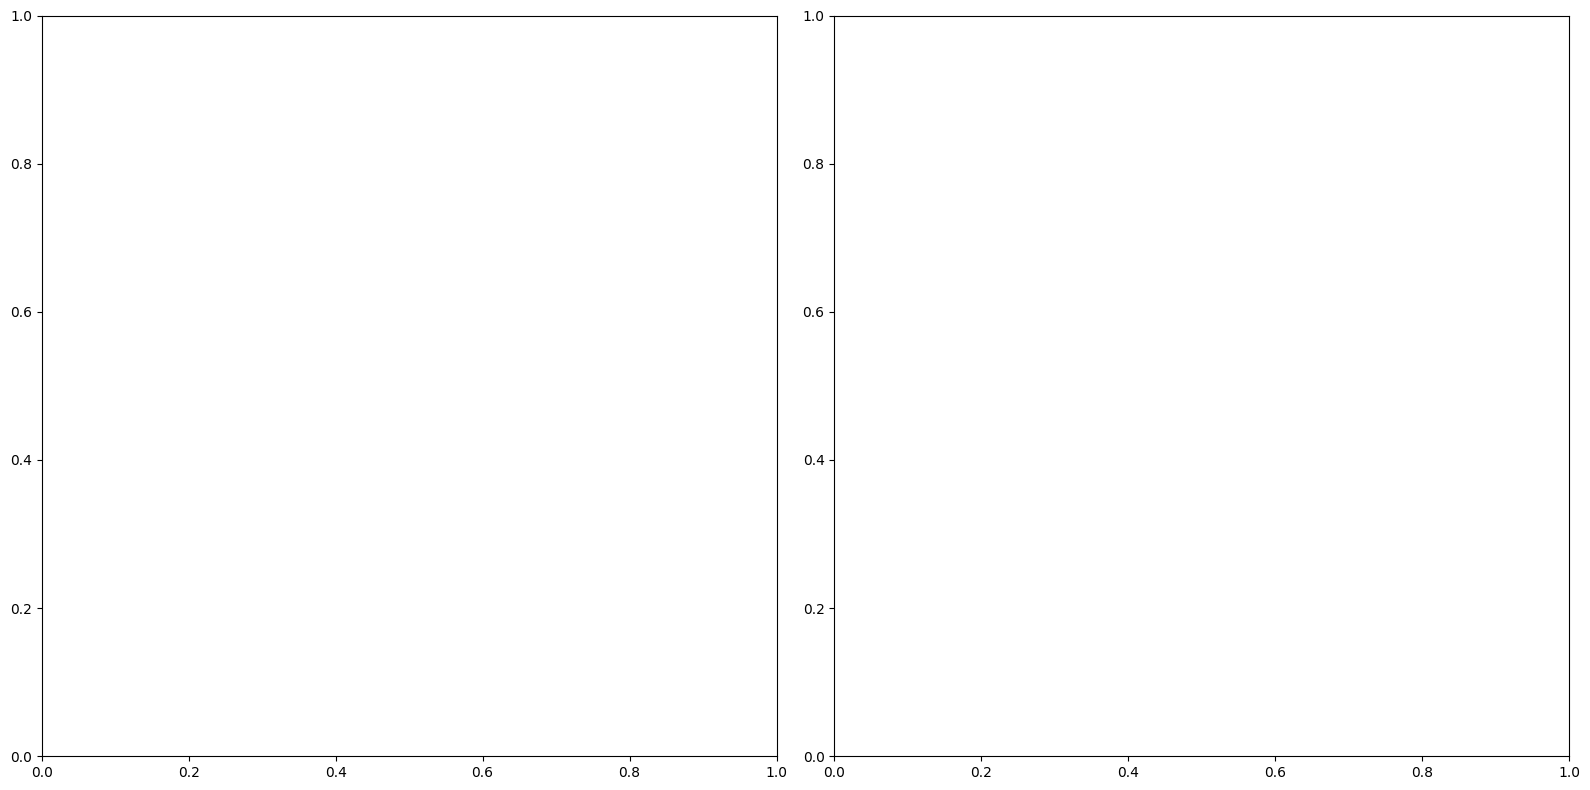

In [11]:
# 정답 vs 예측 시각 비교
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, fname, title in zip(
    axes,
    ["val_batch0_labels.jpg", "val_batch0_pred.jpg"],
    ["정답 (Ground Truth)", "모델 예측"],
):
    fpath = RUN_DIR / fname
    if fpath.exists():
        ax.imshow(Image.open(fpath))
        ax.set_title(title, fontsize=14)
        ax.axis("off")
plt.tight_layout()
plt.show()

## 6. 추론 + 파손율 계산 (단일 이미지)

**파손율 = (damage ∩ total) 픽셀 / total 픽셀**

- damage가 total 바깥으로 튀어나와도 교집합으로 처리
- 전손 케이스(damage와 total이 거의 일치)는 IoU > 0.9로 판단

In [29]:
# 클래스 인덱스 매핑
TOTAL_IDX  = class_names.index("total")  if "total"  in class_names else 0
DAMAGE_IDX = class_names.index("damage") if "damage" in class_names else 1
print(f"total  클래스 인덱스: {TOTAL_IDX}")
print(f"damage 클래스 인덱스: {DAMAGE_IDX}")

total  클래스 인덱스: 1
damage 클래스 인덱스: 0


테스트 이미지: 101_10_0af8095f-d70e-487e-95bf-4fae4f67b121_jpeg.rf.b4b3205a09a4517d377a4f964dc946d2.jpg


Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) 

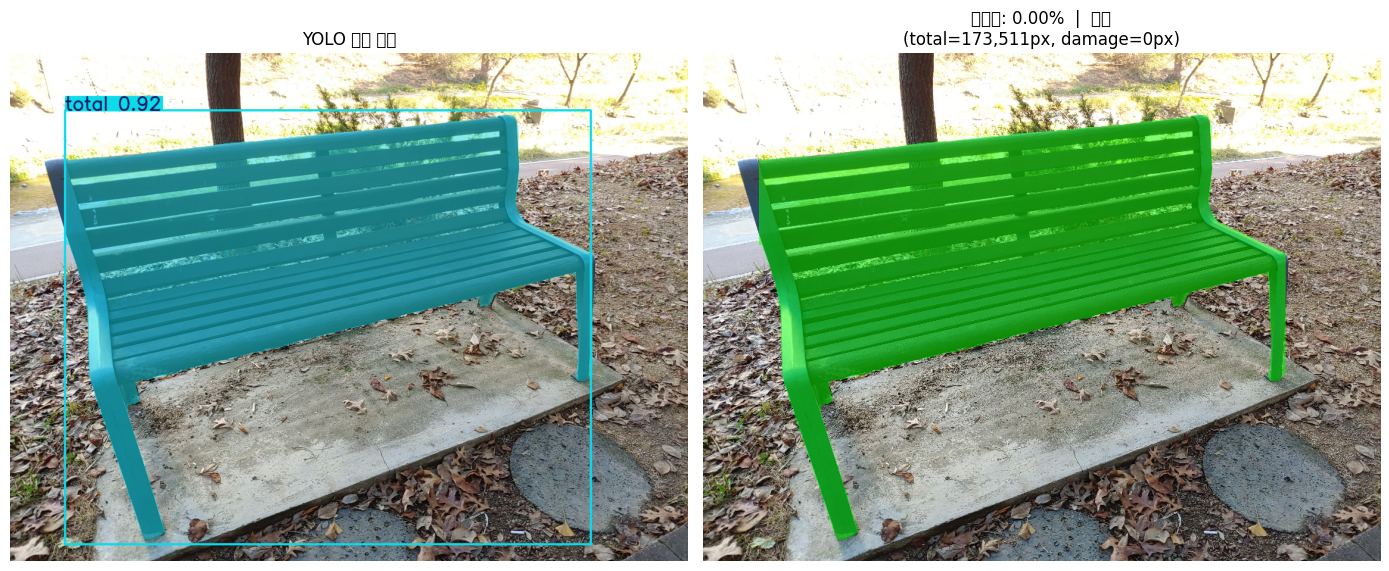


결과: {'total_area': 173511, 'damage_area': 0, 'ratio': 0.0, 'status': '정상'}


In [30]:
def calculate_damage_ratio(model, image_path, conf=0.25, visualize=True):
    """단일 이미지 파손율 계산"""
    results = model(str(image_path), conf=conf, verbose=False)
    r = results[0]
    
    if r.masks is None:
        return {"total_area": 0, "damage_area": 0, "ratio": 0.0, "status": "검출 없음"}
    
    masks = r.masks.data.cpu().numpy()
    clss = r.boxes.cls.cpu().numpy().astype(int)
    
    total_masks = masks[clss == TOTAL_IDX]
    damage_masks = masks[clss == DAMAGE_IDX]
    
    if len(total_masks) == 0:
        return {"total_area": 0, "damage_area": 0, "ratio": 0.0, "status": "total 미검출"}
    
    total_mask = np.any(total_masks, axis=0).astype(bool)
    damage_mask = (
        np.any(damage_masks, axis=0).astype(bool)
        if len(damage_masks) > 0
        else np.zeros_like(total_mask)
    )
    
    damage_in_total = damage_mask & total_mask
    total_area = int(total_mask.sum())
    damage_area = int(damage_in_total.sum())
    ratio = damage_area / total_area if total_area > 0 else 0.0
    
    # 전손 판단
    if len(damage_masks) > 0:
        union = (total_mask | damage_mask).sum()
        iou = (total_mask & damage_mask).sum() / union if union > 0 else 0
        if iou > 0.9:
            ratio = 1.0
    
    # 상태 분류
    if ratio >= 0.8:
        status = "교체 필요 (전손)"
    elif ratio >= 0.3:
        status = "수리 필요"
    elif ratio > 0.05:
        status = "경미한 손상"
    else:
        status = "정상"
    
    result = {
        "total_area": total_area,
        "damage_area": damage_area,
        "ratio": ratio,
        "status": status,
    }
    
    if visualize:
        annotated = cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        axes[0].imshow(annotated)
        axes[0].set_title("YOLO 예측 결과")
        axes[0].axis("off")
        
        img = cv2.imread(str(image_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (total_mask.shape[1], total_mask.shape[0]))
        overlay = img.copy().astype(float)
        overlay[total_mask] = overlay[total_mask] * 0.5 + np.array([0, 128, 0])
        overlay[damage_in_total] = np.array([220, 0, 0])
        overlay = np.clip(overlay, 0, 255).astype(np.uint8)
        
        axes[1].imshow(overlay)
        axes[1].set_title(
            f"파손율: {ratio*100:.2f}%  |  {status}\n"
            f"(total={total_area:,}px, damage={damage_area:,}px)"
        )
        axes[1].axis("off")
        plt.tight_layout()
        plt.show()
    
    return result

# 테스트
test_images = sorted((DATASET_DIR / "test/images").glob("*.*"))
if test_images:
    sample_img = test_images[0]
    print(f"테스트 이미지: {sample_img.name}")
    result = calculate_damage_ratio(model, sample_img)
    print(f"\n결과: {result}")

## 7. 배치 파손율 계산 (test set 전체)

In [31]:
test_dir = DATASET_DIR / "test/images"
test_images = sorted(test_dir.glob("*.*"))
print(f"총 {len(test_images)}장 처리 중...\n")

records = []
for img_path in test_images:
    r = calculate_damage_ratio(model, img_path, visualize=False)
    records.append({
        "image": img_path.name,
        "total_area": r["total_area"],
        "damage_area": r["damage_area"],
        "damage_ratio(%)": round(r["ratio"] * 100, 2),
        "status": r["status"],
    })

df = pd.DataFrame(records)
df.to_csv("damage_ratio_results.csv", index=False, encoding="utf-8-sig")
print("✅ damage_ratio_results.csv 저장 완료\n")
df.head(20)

총 67장 처리 중...

✅ damage_ratio_results.csv 저장 완료



,image,total_area,damage_area,damage_ratio(%),status
0,101_10_0af8095f-d70e-487e-95bf-4fae4f67b121_jp...,173511,0,0.00,정상
1,101_10_0c003256-7b83-4747-8fc3-22f31368622a_jp...,52773,0,0.00,정상
2,101_30_39876545-9327-4c8b-a9b1-9c694791f872_jp...,91863,0,0.00,정상
3,101_30_5f1c211b-5b94-4bf6-a11e-31bb8dd757f0_jp...,96243,0,0.00,정상
4,101_30_65194428-bbe6-402c-a08d-088b85df2be3_jp...,135727,3024,2.23,정상
5,101_30_6e28d9b5-2475-4f91-a6d3-800e8d52ae87_jp...,129579,191,0.15,정상
6,101_30_7f86b7cd-192b-4563-999c-03dbd899a001_jp...,84257,0,0.00,정상
7,101_30_8973e853-9478-4242-a817-341eea836e40_jp...,148140,38,0.03,정상
8,101_30_fbfd2b5f-c42e-48b6-b1e5-dc31e5a559e5_jp...,90701,40,0.04,정상
9,102_10_0a38cae6-93dc-4caa-9fac-801db53d1e11_jp...,77916,0,0.00,정상


In [ ]:
# 통계 및 시각화
print("📊 상태별 분포:")
print(df["status"].value_counts())
print("\n📈 파손율 통계:")
print(df["damage_ratio(%)"].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df["damage_ratio(%)"], bins=20, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].set_xlabel("파손율 (%)")
axes[0].set_ylabel("이미지 수")
axes[0].set_title("파손율 분포")
axes[0].grid(alpha=0.3)

status_counts = df["status"].value_counts()
axes[1].pie(status_counts.values, labels=status_counts.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("상태 분포")
plt.tight_layout()
plt.show()

In [ ]:
# 샘플 몇 장 시각화 (파손율 고/중/저)
df_sorted = df.sort_values("damage_ratio(%)", ascending=False)
samples = pd.concat([
    df_sorted.head(2),
    df_sorted.iloc[len(df_sorted)//2 : len(df_sorted)//2 + 2],
    df_sorted.tail(1),
])

for _, row in samples.iterrows():
    img_path = test_dir / row["image"]
    print(f"\n--- {row['image']} | 파손율 {row['damage_ratio(%)']}% | {row['status']} ---")
    calculate_damage_ratio(model, img_path, visualize=True)

In [15]:
# ============================================================
# 품목별 mAP50 계산 (파일명 앞 3글자로 품목 구분 + 매핑 규칙)
# ============================================================
import shutil
from collections import defaultdict

BEST_WEIGHTS = Path("/home/piai/바탕화면/YOLO/runs/segment/damage_seg/yolov8s_v1/weights/best.pt")
model = YOLO(str(BEST_WEIGHTS))

EVAL_SPLIT = "test"   # "valid"로 바꾸면 검증셋 기준

src_img_dir = DATASET_DIR / EVAL_SPLIT / "images"
src_lbl_dir = DATASET_DIR / EVAL_SPLIT / "labels"

# --- prefix 정규화 규칙 ---
PREFIX_MAP = {
    "Cha": "101",
    "Gem": "101",
    "img": "602",
}

def normalize_prefix(stem: str) -> str:
    p3 = stem[:3]
    return PREFIX_MAP.get(p3, p3)   # 매핑에 있으면 치환, 없으면 원본 3글자

# 1) 파일명 앞 3글자(매핑 적용)로 품목 그룹핑
groups = defaultdict(list)
for img_path in src_img_dir.glob("*.*"):
    prefix = normalize_prefix(img_path.stem)
    groups[prefix].append(img_path)

print(f"총 {len(groups)}개 품목 발견")
for prefix, files in sorted(groups.items()):
    print(f"  [{prefix}] {len(files)}장")

# 2) 품목별로 임시 데이터셋 폴더 만들어서 평가
WORK_DIR = Path("per_category_eval")
if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)
WORK_DIR.mkdir(parents=True)

per_class_records = []
summary_records   = []

for prefix, img_files in sorted(groups.items()):
    cat_dir = WORK_DIR / prefix
    (cat_dir / "images").mkdir(parents=True, exist_ok=True)
    (cat_dir / "labels").mkdir(parents=True, exist_ok=True)

    for img in img_files:
        dst_img = cat_dir / "images" / img.name
        dst_lbl = cat_dir / "labels" / (img.stem + ".txt")
        src_lbl = src_lbl_dir / (img.stem + ".txt")
        try:
            if not dst_img.exists():
                os.symlink(img.resolve(), dst_img)
            if src_lbl.exists() and not dst_lbl.exists():
                os.symlink(src_lbl.resolve(), dst_lbl)
        except OSError:
            shutil.copy2(img, dst_img)
            if src_lbl.exists():
                shutil.copy2(src_lbl, dst_lbl)

    cat_yaml = cat_dir / "data.yaml"
    yaml.dump({
        "path":  str(cat_dir.resolve()),
        "train": "images",
        "val":   "images",
        "test":  "images",
        "nc":    len(class_names),
        "names": class_names,
    }, cat_yaml.open("w"), sort_keys=False, allow_unicode=True)

    print(f"\n🔍 [{prefix}] 평가 중... (n={len(img_files)})")
    metrics = model.val(
        data=str(cat_yaml),
        split="val",
        verbose=False,
        plots=False,
        save_json=False,
        project="per_category_eval",
        name=f"run_{prefix}",
        exist_ok=True,
    )

    summary_records.append({
        "품목(prefix)": prefix,
        "이미지수":     len(img_files),
        "mAP50":        round(float(metrics.seg.map50), 4),
        "mAP50-95":     round(float(metrics.seg.map), 4),
        "Precision":    round(float(metrics.seg.mp), 4),
        "Recall":       round(float(metrics.seg.mr), 4),
    })

    for i, name in model.names.items():
        try:
            ap50 = float(metrics.seg.ap50[i])
            ap   = float(metrics.seg.ap[i])
        except (IndexError, TypeError):
            ap50, ap = float("nan"), float("nan")
        per_class_records.append({
            "품목(prefix)": prefix,
            "클래스":       name,
            "mAP50":        round(ap50, 4),
            "mAP50-95":     round(ap, 4),
        })

# 3) 결과 DataFrame & 저장
summary_df   = pd.DataFrame(summary_records).sort_values("mAP50", ascending=False)
per_class_df = pd.DataFrame(per_class_records)

summary_df.to_csv("per_category_summary.csv", index=False, encoding="utf-8-sig")
per_class_df.to_csv("per_category_per_class.csv", index=False, encoding="utf-8-sig")

print("\n" + "=" * 60)
print("📊 품목별 mAP50 요약 (mask 기준)")
print("=" * 60)
print(summary_df.to_string(index=False))

print("\n" + "=" * 60)
print("📊 품목 × 클래스 상세")
print("=" * 60)
pivot = per_class_df.pivot(index="품목(prefix)", columns="클래스", values="mAP50")
print(pivot.round(4))

총 9개 품목 발견
  [101] 9장
  [102] 10장
  [504] 9장
  [505] 5장
  [506] 9장
  [602] 4장
  [701] 6장
  [803] 6장
  [804] 9장

🔍 [101] 평가 중... (n=9)
Ultralytics 8.4.40 🚀 Python-3.10.20 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2080, 7786MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,780,374 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3683.5±1086.1 MB/s, size: 2536.8 KB)
val: Scanning /home/piai/바탕화면/YOLO/per_category_eval/101/labels... 9 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 9/9 450.2it/s 0.0s
val: New cache created: /home/piai/바탕화면/YOLO/per_category_eval/101/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.8s/it 1.8s
                   all          9         21      0.575      0.591      0.582      0.483      0.639      0.545      0.547      0.445
Speed: 1.2ms preprocess, 15.0ms inference, 0.0ms loss, 1.8ms postprocess

In [20]:
# ============================================================
# 품목별 mAP50 계산 (클래스 인덱스 매핑 버그 수정 버전)
# ============================================================
import shutil
from collections import defaultdict

BEST_WEIGHTS = Path("/home/piai/바탕화면/YOLO/runs/segment/damage_seg/yolov8s_v1/weights/best.pt")
model = YOLO(str(BEST_WEIGHTS))

EVAL_SPLIT = "valid"

src_img_dir = DATASET_DIR / EVAL_SPLIT / "images"
src_lbl_dir = DATASET_DIR / EVAL_SPLIT / "labels"

PREFIX_MAP = {"Cha": "101", "Gem": "101", "img": "602"}

def normalize_prefix(stem: str) -> str:
    p3 = stem[:3]
    return PREFIX_MAP.get(p3, p3)

groups = defaultdict(list)
for img_path in src_img_dir.glob("*.*"):
    prefix = normalize_prefix(img_path.stem)
    groups[prefix].append(img_path)

print(f"총 {len(groups)}개 품목 발견")
for prefix, files in sorted(groups.items()):
    print(f"  [{prefix}] {len(files)}장")

WORK_DIR = Path("per_category_eval")
if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)
WORK_DIR.mkdir(parents=True)

per_class_records = []
summary_records   = []

for prefix, img_files in sorted(groups.items()):
    cat_dir = WORK_DIR / prefix
    (cat_dir / "images").mkdir(parents=True, exist_ok=True)
    (cat_dir / "labels").mkdir(parents=True, exist_ok=True)

    for img in img_files:
        dst_img = cat_dir / "images" / img.name
        dst_lbl = cat_dir / "labels" / (img.stem + ".txt")
        src_lbl = src_lbl_dir / (img.stem + ".txt")
        try:
            if not dst_img.exists():
                os.symlink(img.resolve(), dst_img)
            if src_lbl.exists() and not dst_lbl.exists():
                os.symlink(src_lbl.resolve(), dst_lbl)
        except OSError:
            shutil.copy2(img, dst_img)
            if src_lbl.exists():
                shutil.copy2(src_lbl, dst_lbl)

    cat_yaml = cat_dir / "data.yaml"
    yaml.dump({
        "path":  str(cat_dir.resolve()),
        "train": "images",
        "val":   "images",
        "test":  "images",
        "nc":    len(class_names),
        "names": class_names,
    }, cat_yaml.open("w"), sort_keys=False, allow_unicode=True)

    print(f"\n🔍 [{prefix}] 평가 중... (n={len(img_files)})")
    metrics = model.val(
        data=str(cat_yaml),
        split="val",
        verbose=False,
        plots=False,
        save_json=False,
        project="per_category_eval",
        name=f"run_{prefix}",
        exist_ok=True,
    )

    summary_records.append({
        "품목(prefix)": prefix,
        "이미지수":     len(img_files),
        "mAP50":        round(float(metrics.seg.map50), 4),
        "mAP50-95":     round(float(metrics.seg.map), 4),
        "Precision":    round(float(metrics.seg.mp), 4),
        "Recall":       round(float(metrics.seg.mr), 4),
    })

    # ⭐ 여기가 수정된 핵심 부분
    ap50_arr   = metrics.seg.ap50           # 존재하는 클래스만의 AP50 배열
    ap_arr     = metrics.seg.ap             # 존재하는 클래스만의 AP50-95 배열
    ap_cls_idx = metrics.ap_class_index     # 각 원소가 어느 클래스 인덱스인지

    # 전체 클래스를 NaN으로 초기화
    ap50_by_cls = {i: float("nan") for i in model.names}
    ap_by_cls   = {i: float("nan") for i in model.names}

    # 실제 존재하는 클래스에만 값 채우기
    for arr_pos, cls_idx in enumerate(ap_cls_idx):
        ap50_by_cls[int(cls_idx)] = float(ap50_arr[arr_pos])
        ap_by_cls[int(cls_idx)]   = float(ap_arr[arr_pos])

    for i, name in model.names.items():
        per_class_records.append({
            "품목(prefix)": prefix,
            "클래스":       name,
            "mAP50":        round(ap50_by_cls[i], 4),
            "mAP50-95":     round(ap_by_cls[i], 4),
        })

summary_df   = pd.DataFrame(summary_records).sort_values("mAP50", ascending=False)
per_class_df = pd.DataFrame(per_class_records)

summary_df.to_csv("per_category_summary.csv", index=False, encoding="utf-8-sig")
per_class_df.to_csv("per_category_per_class.csv", index=False, encoding="utf-8-sig")

print("\n" + "=" * 60)
print("📊 품목별 mAP50 요약 (mask 기준)")
print("=" * 60)
print(summary_df.to_string(index=False))

print("\n" + "=" * 60)
print("📊 품목 × 클래스 상세 (mAP50)")
print("=" * 60)
pivot = per_class_df.pivot(index="품목(prefix)", columns="클래스", values="mAP50")
print(pivot.round(4))

총 9개 품목 발견
  [101] 10장
  [102] 7장
  [504] 9장
  [505] 6장
  [506] 7장
  [602] 9장
  [701] 4장
  [803] 9장
  [804] 7장

🔍 [101] 평가 중... (n=10)
Ultralytics 8.4.40 🚀 Python-3.10.20 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2080, 7786MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,780,374 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3830.7±847.2 MB/s, size: 2016.2 KB)
val: Scanning /home/piai/바탕화면/YOLO/per_category_eval/101/labels... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 729.0it/s 0.0s
val: New cache created: /home/piai/바탕화면/YOLO/per_category_eval/101/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.6s/it 1.6s
                   all         10         23      0.874      0.692      0.693      0.548      0.874      0.692       0.69      0.525
Speed: 1.6ms preprocess, 13.8ms inference, 0.0ms loss, 2.3ms postproc

In [22]:
# ============================================================
# 품목별 mAP50 계산 (valid + test 합쳐서 평가)
# ============================================================
import shutil
from collections import defaultdict

BEST_WEIGHTS = Path("/home/piai/바탕화면/YOLO/runs/segment/damage_seg/yolov8s_v1/weights/best.pt")
model = YOLO(str(BEST_WEIGHTS))

# 합칠 split 목록
EVAL_SPLITS = ["valid", "test"]

# --- prefix 정규화 규칙 ---
PREFIX_MAP = {
    "Cha": "101",
    "Gem": "101",
    "img": "602",
}

def normalize_prefix(stem: str) -> str:
    p3 = stem[:3]
    return PREFIX_MAP.get(p3, p3)

# 1) valid + test의 모든 이미지를 품목별로 그룹핑 (split 정보도 보존)
groups = defaultdict(list)   # prefix → [(split, img_path), ...]
for split in EVAL_SPLITS:
    img_dir = DATASET_DIR / split / "images"
    if not img_dir.exists():
        print(f"⚠️  {split} 폴더 없음, 건너뜀")
        continue
    for img_path in img_dir.glob("*.*"):
        prefix = normalize_prefix(img_path.stem)
        groups[prefix].append((split, img_path))

print(f"총 {len(groups)}개 품목 발견 (valid + test 합침)")
for prefix, items in sorted(groups.items()):
    split_counts = defaultdict(int)
    for split, _ in items:
        split_counts[split] += 1
    breakdown = ", ".join(f"{s}={n}" for s, n in split_counts.items())
    print(f"  [{prefix}] 총 {len(items)}장 ({breakdown})")

# 2) 품목별로 임시 데이터셋 폴더 만들어서 평가
WORK_DIR = Path("per_category_eval_merged")
if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)
WORK_DIR.mkdir(parents=True)

per_class_records = []
summary_records   = []

for prefix, items in sorted(groups.items()):
    cat_dir = WORK_DIR / prefix
    (cat_dir / "images").mkdir(parents=True, exist_ok=True)
    (cat_dir / "labels").mkdir(parents=True, exist_ok=True)

    for split, img in items:
        # valid/test에 같은 파일명이 있을 수 있으므로 split 접두사 추가
        new_stem = f"{split}__{img.stem}"
        new_name = f"{new_stem}{img.suffix}"
        
        dst_img = cat_dir / "images" / new_name
        dst_lbl = cat_dir / "labels" / (new_stem + ".txt")
        src_lbl = DATASET_DIR / split / "labels" / (img.stem + ".txt")
        
        try:
            if not dst_img.exists():
                os.symlink(img.resolve(), dst_img)
            if src_lbl.exists() and not dst_lbl.exists():
                os.symlink(src_lbl.resolve(), dst_lbl)
        except OSError:
            shutil.copy2(img, dst_img)
            if src_lbl.exists():
                shutil.copy2(src_lbl, dst_lbl)

    cat_yaml = cat_dir / "data.yaml"
    yaml.dump({
        "path":  str(cat_dir.resolve()),
        "train": "images",
        "val":   "images",
        "test":  "images",
        "nc":    len(class_names),
        "names": class_names,
    }, cat_yaml.open("w"), sort_keys=False, allow_unicode=True)

    print(f"\n🔍 [{prefix}] 평가 중... (n={len(items)})")
    metrics = model.val(
        data=str(cat_yaml),
        split="val",
        verbose=False,
        plots=False,
        save_json=False,
        project="per_category_eval_merged",
        name=f"run_{prefix}",
        exist_ok=True,
    )

    summary_records.append({
        "품목(prefix)": prefix,
        "이미지수":     len(items),
        "mAP50":        round(float(metrics.seg.map50), 4),
        "mAP50-95":     round(float(metrics.seg.map), 4),
        "Precision":    round(float(metrics.seg.mp), 4),
        "Recall":       round(float(metrics.seg.mr), 4),
    })

    # 클래스 인덱스 매핑 (수정된 방식)
    ap50_arr   = metrics.seg.ap50
    ap_arr     = metrics.seg.ap
    ap_cls_idx = metrics.ap_class_index

    ap50_by_cls = {i: float("nan") for i in model.names}
    ap_by_cls   = {i: float("nan") for i in model.names}
    for arr_pos, cls_idx in enumerate(ap_cls_idx):
        ap50_by_cls[int(cls_idx)] = float(ap50_arr[arr_pos])
        ap_by_cls[int(cls_idx)]   = float(ap_arr[arr_pos])

    for i, name in model.names.items():
        per_class_records.append({
            "품목(prefix)": prefix,
            "클래스":       name,
            "mAP50":        round(ap50_by_cls[i], 4),
            "mAP50-95":     round(ap_by_cls[i], 4),
        })

# 3) 결과 DataFrame & 저장
summary_df   = pd.DataFrame(summary_records).sort_values("mAP50", ascending=False)
per_class_df = pd.DataFrame(per_class_records)

summary_df.to_csv("per_category_summary_merged.csv", index=False, encoding="utf-8-sig")
per_class_df.to_csv("per_category_per_class_merged.csv", index=False, encoding="utf-8-sig")

print("\n" + "=" * 60)
print("📊 품목별 mAP50 요약 (valid + test 합침, mask 기준)")
print("=" * 60)
print(summary_df.to_string(index=False))

print("\n" + "=" * 60)
print("📊 품목 × 클래스 상세 (mAP50)")
print("=" * 60)
pivot50 = per_class_df.pivot(index="품목(prefix)", columns="클래스", values="mAP50")
print(pivot50.round(4))

print("\n" + "=" * 60)
print("📊 품목 × 클래스 상세 (mAP50-95)")
print("=" * 60)
pivot95 = per_class_df.pivot(index="품목(prefix)", columns="클래스", values="mAP50-95")
print(pivot95.round(4))

총 9개 품목 발견 (valid + test 합침)
  [101] 총 19장 (valid=10, test=9)
  [102] 총 17장 (valid=7, test=10)
  [504] 총 18장 (valid=9, test=9)
  [505] 총 11장 (valid=6, test=5)
  [506] 총 16장 (valid=7, test=9)
  [602] 총 13장 (valid=9, test=4)
  [701] 총 10장 (valid=4, test=6)
  [803] 총 15장 (valid=9, test=6)
  [804] 총 16장 (valid=7, test=9)

🔍 [101] 평가 중... (n=19)
Ultralytics 8.4.40 🚀 Python-3.10.20 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2080, 7786MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,780,374 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3994.3±244.1 MB/s, size: 2559.6 KB)
val: Scanning /home/piai/바탕화면/YOLO/per_category_eval_merged/101/labels... 19 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 19/19 582.8it/s 0.0s
val: New cache created: /home/piai/바탕화면/YOLO/per_category_eval_merged/101/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━

## 다음 스텝 가이드

섹션 5의 **damage mAP** 결과에 따라:

| damage mAP50-95 | 다음 액션 |
|---|---|
| ≥ 0.5 | 🎉 완료! `best.pt`로 배포 가능 |
| 0.35 ~ 0.5 | `imgsz=896`으로 재학습 |
| 0.2 ~ 0.35 | `yolo11s-seg` 또는 `yolo11m-seg`로 업그레이드 |
| < 0.2 | 라벨 품질 점검, 데이터 추가 수집 |

**재학습 시**: 
- 섹션 4의 `YOLO("yolo11n-seg.pt")` → `YOLO("yolo11s-seg.pt")` 교체
- 학습 셀의 `name="yolo11n_v1"` → `name="yolo11s_v1"` 등으로 변경
- 섹션 5의 `RUN_DIR` 경로도 새 이름으로 변경